# Ejercicio 2
* Considere una población continua x(t), con una dinámica multiplica-
tiva en tiempo discreto y un ruido aditivo:
x(t + 1) = a x(t) + z(t), (1)
donde la variable estocástica z(t) tiene distribución gaussiana con me-
dia cero y desviación estándar σ. Simule una docena de trayectorias
del sistema, partiendo de x(0) = 1 y usando a = 1.05, σ = 0.2, hasta
tiempo 50. Compare las trayectorias estocásticas con la correspondien-
te dinámica sin ruido, en un gráco de x en función del tiempo. Simule
un ensemble de trayectorias y calcule la distribución de probabilidad
P (x, t), y grafíquela (ya sea en 3D, o usando t como parámetro).
Haga lo mismo para una dinámica con ruido multiplicativo:
x(t + 1) = a x(t) + z(t) x(t).

Simulamos un crecimiento exploonencial sin muertes

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

Para la ecaución de Langevin escribimos una dinámica multiplicativa en tiempo discreto con ruido aditivo y multiplicativo.

$x(t + 1) = a x(t) + z(t)$

$x(t + 1) = a x(t) + z(t) x(t)$

donde la variable estocástica $z(t)$ tiene una distribución gaussiana con media 0 y desviación estándar $\sigma$.

Simulamos una docena de trayectorias del sistema, partiendo de $x(0) = 1$ y usando $a = 1.05$, $\sigma = 0.2$, hasta tiempo 50.

Compararemos las trayectorias estocásticas con la correspondiente dinámica sin ruido, en un gráfico de $x$ en función del tiempo. Simularemos un ensemble de trayectorias y calcularemos la distribución de probabilidad $P(x,t)$, y la graficaremos (ya sea en 3D, o usando $t$ como parámetro).

In [89]:
def simula_tray_sr(tf):
    # Tasa de crecimiento
    a = 1.05
    # Población inicial
    n0 = 1

    # Simulación del crecimiento exponencial
    x = np.zeros(tf)
    x[0] = n0

    for t in range(1, tf):
        x[t] = a * x[t-1]

    return x

In [90]:
def simula_evolucion_aditivo(tf):
    # Tasa de crecimiento
    a = 1.05
    # Población inicial
    n0 = 1

    # Ruido blanco gaussiano
    mu, sigma = 0 , 0.2

    z = np.random.normal(mu, sigma, tf)

    # Simulación del crecimiento exponencial
    x = np.zeros(tf)
    x[0] = n0
    for n in range(1, tf):
        x[n] = a*x[n-1] + z[n-1]
        if x[n] <= 0:
            x[n] = 0
            break
        
    if (len(x) < tf):
        x = np.resize(x, tf)

    return x

In [91]:
# Tiempo final de simulación 
tf = 50
# Numero de simulaciones
n_sim = 12

# Simulación de la evolución de distintas poblaciones
ensamble = np.zeros((tf, n_sim))

for i in range(n_sim):
    ensamble[:, i] = simula_evolucion_aditivo(tf)

sin_ruido = simula_tray_sr(tf)

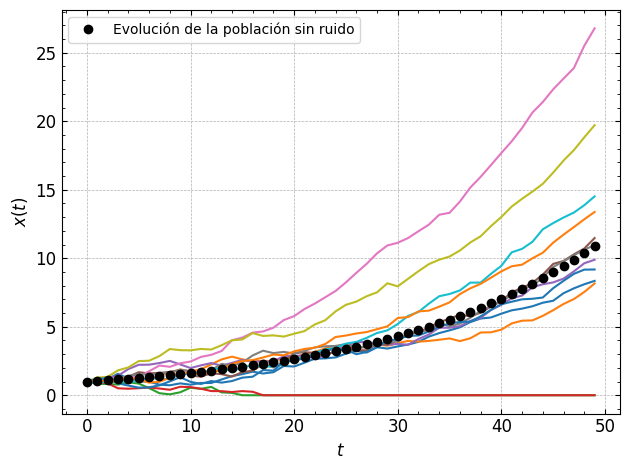

In [92]:
plt.plot(ensamble)
plt.plot(sin_ruido, 'ko', label='Evolución de la población sin ruido')
plt.xlabel('$t$', fontsize = 12)
plt.ylabel('$x(t)$', fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
# plt.savefig('LangevinAditivo.pdf')
plt.show()

In [93]:
# Numero de simulaciones
n_sim = 1000

# Simulación de la evolución de distintas para sacar el histograma
ensamble2 = np.zeros((tf, n_sim))

for i in range(n_sim):
    ensamble2[:, i] = simula_evolucion_aditivo(tf)

sin_ruido = simula_tray_sr(tf)

z = np.arange(0, tf, 2)
h = tf//2 * [0]
b = tf//2 * [0]

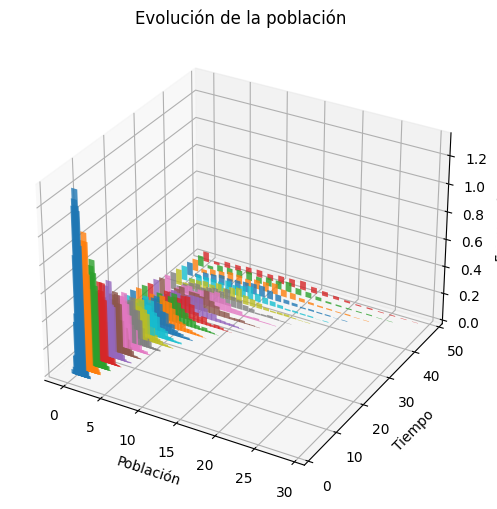

In [94]:
for idx, i in enumerate(range(0, tf, 2)):
    h[idx], b[idx] = np.histogram(ensamble2[i, :], bins=20, density=True)

fig, ax = plt.figure(figsize=(6,6)), plt.axes(projection='3d')

for i in range(1, tf//2):
    ax.bar(b[i][:-1], h[i], z[i], zdir='y', alpha=0.8)

ax.set_xlabel('Población')
ax.set_ylabel('Tiempo')
ax.set_zlabel('Frecuencia')
ax.set_title('Evolución de la población')
plt.savefig('HistogramaAditivo.pdf')
plt.show()

----
* Población con ruido multiplicativo

In [95]:
def simula_evolucion_multiplicativo(tf):
    # Tasa de crecimiento
    a = 1.05
    # Población inicial
    n0 = 1

    # Ruido blanco gaussiano
    mu, sigma = 0 , 0.2

    z = np.random.normal(mu, sigma, tf)

    # Simulación del crecimiento exponencial
    x = np.zeros(tf)
    x[0] = n0
    for n in range(1, tf):
        x[n] = a * x[n-1] + z[n-1]*x[n-1]
        if x[n] <= 0:
            x[n] = 0
            break
        
    if (len(x) < tf):
        x = np.resize(x, tf)

    return x

In [96]:
# Tiempo final de simulación 
tf = 50
# Numero de simulaciones
n_sim = 12

# Simulación de la evolución de distintas poblaciones
ensamble = np.zeros((tf, n_sim))

for i in range(n_sim):
    ensamble[:, i] = simula_evolucion_multiplicativo(tf)

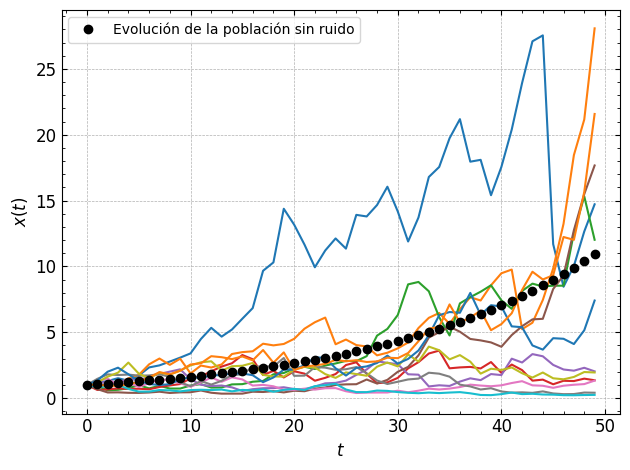

In [101]:
plt.plot(ensamble)
plt.plot(sin_ruido, 'ko', label='Evolución de la población sin ruido')
plt.xlabel('$t$', fontsize = 12)
plt.ylabel('$x(t)$', fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('LangevinMultiplicativo.pdf')
plt.show()

In [102]:
# Tiempo final de simulación 
tf = 50
# Numero de simulaciones
n_sim = 1000

# Simulación de la evolución de distintas poblaciones
ensamble2 = np.zeros((tf, n_sim))

for i in range(1,n_sim):
    ensamble2[:, i] = simula_evolucion_multiplicativo(tf)

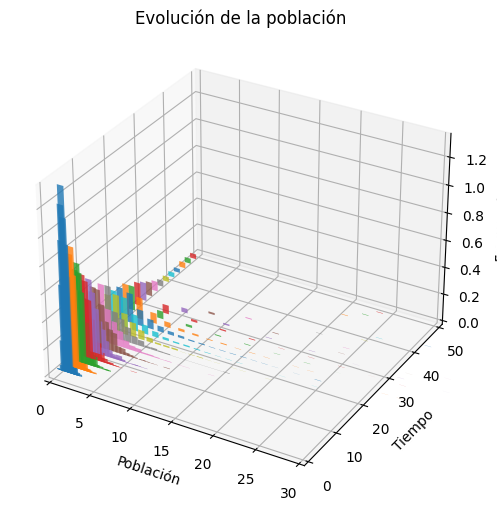

In [104]:
for idx, i in enumerate(range(0, tf, 2)):
    h[idx], b[idx] = np.histogram(ensamble2[i, :], bins=20, density=True)

fig, ax = plt.figure(figsize=(6,6)), plt.axes(projection='3d')

for i in range(1, tf//2):
    ax.bar(b[i][:-1], h[i], z[i], zdir='y', alpha=0.8)

ax.set_xlim(0, 30)
ax.set_xlabel('Población')
ax.set_ylabel('Tiempo')
ax.set_zlabel('Frecuencia')
ax.set_title('Evolución de la población')
plt.savefig('HistogramaMultiplicativo.pdf')
plt.show()

Lo que ocurre es que la población al crecer de manera exponencial tiene también un efecto amplificador del ruido cuando este es multilplicativo, por lo tanto la población crece de manera exponencial pero con un ruido que se amplifica con el tiempo. 

Por otro lado en el ruido aditivo el ruido es constante por lo cual no ocurren dispersiones tan abruptas como en el caso multiplicativo.